In [1]:
import torch.nn as nn
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import pickle
from model import CodyConvNet, device
from utils import classes


(null): No such file or directory
(null): No such file or directory


In [2]:
with open("best_params.pkl", "rb") as f:
    parameters = pickle.load(f)
model = CodyConvNet(
    image_dim=96, 
    n_classes=len(classes),
    conv_neuron_rate=parameters["cnr"],
    dense_neuron_rate=parameters["dnr"],
    dropout=parameters["dropout"],
    dropout2d=parameters["dropout2d"]
).to(device=device)

In [3]:
path = "cody_cnn_20260614_221151.pth"
model.load_state_dict(torch.load(path, weights_only=True))
model.eval()

CodyConvNet(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True

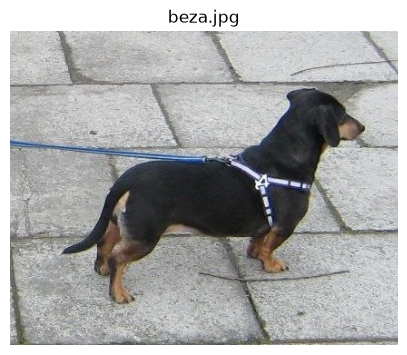

  1. DOG          (Pewność:  58.9%)
  2. HORSE        (Pewność:  27.0%)
  3. BIRD         (Pewność:   5.4%)
File: custom_data/beza.jpg


[('dog', 58.89304280281067),
 ('horse', 26.959925889968872),
 ('bird', 5.3939104080200195)]

In [8]:
def predict_single_image(image_path: str, model: torch.nn.Module, device):
    model.eval()
    
    # 2. Definiujemy "Lejek" (Transformacje) dla pojedynczego zdjęcia
    inference_transform = transforms.Compose([
        transforms.Resize((96, 96)), # Zmuszamy dowolne zdjęcie do bycia 96x96
        transforms.ToTensor(),       # Konwersja z PIL Image na Tensor (skala 0.0 - 1.0)
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)) # Twoja normalizacja
    ])
    
    # 3. Ładowanie i procesowanie obrazka
    try:
        # Konwersja na RGB zapobiega błędom, gdy wrzucisz np. zdjęcie czarno-białe lub z przezroczystością (PNG)
        img = Image.open(image_path).convert('RGB') 
    except FileNotFoundError:
        print(f"Nie znaleziono pliku: {image_path}")
        return
        
    img_tensor = inference_transform(img) # Wynik: [3, 96, 96]
    
    # Dodanie wymiaru batcha: [3, 96, 96] -> [1, 3, 96, 96] i wysłanie na kartę/procesor
    img_tensor = img_tensor.unsqueeze(0).to(device)
    
    # 4. Przepuszczenie przez model (bez liczenia gradientów!)
    with torch.no_grad():
        output = model(img_tensor)
        
        # Opcjonalnie: przepuszczamy przez Softmax, żeby uzyskać pewność procentową
        probabilities = torch.nn.functional.softmax(output, dim=1)[0]
        
        # Argmax wybiera indeks zwycięzcy
        top_probs, top_indices = torch.topk(probabilities, k=3, dim=0)
        
    # 5. Ładne formatowanie wyniku
    top3_results = []
    
    # Pętla iterująca po trzech najlepszych wynikach
    for i in range(3):
        # Wyciągamy wartość z tensora za pomocą .item()
        confidence = top_probs[i].item() * 100
        class_idx = top_indices[i].item()
        class_name = classes[class_idx]
        
        print(f"  {i+1}. {class_name.upper():<12} (Pewność: {confidence:5.1f}%)")
        top3_results.append((class_name, confidence))
    
    print(f"File: {image_path}")
    
    return top3_results


# for i in range(1,7):
#     if i == 3:
#         continue
#     image_path = f"custom_data/novera{i}.jpg"
#     img = Image.open(image_path).convert('RGB') 
#     plt.figure(figsize=(5, 5)) 
#     plt.imshow(img)
#     plt.axis('off')
#     plt.title(f"novera{i}.jpg")
#     plt.show()
#     predict_single_image(image_path, model, device)

image_path = f"custom_data/beza.jpg"
img = Image.open(image_path).convert('RGB') 
plt.figure(figsize=(5, 5)) 
plt.imshow(img)
plt.axis('off')
plt.title(f"beza.jpg")
plt.show()
predict_single_image(image_path, model, device)